# VLM Evaluation — Caption Generation & VQA

Tests the trained `LM_2_VLM` checkpoint on:
1. **Caption generation** — given an image, generate a free-form description
2. **Visual question answering** — given an image + question, generate an answer
3. **Side-by-side comparison** — generated caption vs ground-truth MSCOCO caption
4. **Custom image test** — run on any image path you provide

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
from PIL import Image
from pathlib import Path
from transformers import ViTImageProcessor, AutoTokenizer

from networks.lm_to_vlm import LM_2_VLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## 2. Load Model

In [2]:
CHECKPOINT  = "../models_trained_vlm/vlm_peft/best"   # change to /final or /latest if needed
MODEL_NAME  = "HuggingFaceTB/SmolLM-135M-Instruct"
QFORMER_PATH = "../models_trained/trained_qformer_mscoco/best/qformer"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = LM_2_VLM(
    model_name=MODEL_NAME,
    qformer_model_path=QFORMER_PATH,
    pad_token_id=tokenizer.pad_token_id,
)
model.load_checkpoint(CHECKPOINT)
model.to(device).eval()

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

print(f"Model loaded from: {CHECKPOINT}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

trainable params: 19,537,920 || all params: 154,052,928 || trainable%: 12.6826
Loaded QFormer weights.
Loaded Adapter weights.
Loaded LoRA Adapter weights.
Model loaded from: ../models_trained_vlm/vlm_peft/best


## 3. Helper Functions

In [3]:
def preprocess_image(pil_image):
    """PIL image → pixel_values tensor [1, 3, 224, 224] on device."""
    pixel_values = vit_processor(images=pil_image, return_tensors="pt").pixel_values
    return pixel_values.to(device)


def make_prefix(prompt_text):
    """Format a user prompt with chat template → token id tensor [1, T]."""
    text = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": "Answer the user's question truthfully"},
            {"role": "user",   "content": prompt_text},
        ],
        tokenize=False,
        add_generation_prompt=False,
    )
    ids = torch.tensor([tokenizer.encode(text)]).to(device)
    return ids


@torch.no_grad()
def generate_caption(
    pil_image,
    prompt="Describe this image in detail.",
    max_new_tokens=80,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2,
):
    """Generate a caption/answer for a single PIL image."""
    pixel_values = preprocess_image(pil_image)
    prefix_ids   = make_prefix(prompt)

    output_ids = model.generate(
        img=pixel_values,
        prefix_ids=prefix_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
    )

    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated.strip()


def load_mscoco_samples(n=6, shard="00000"):
    """Load n images + ground-truth captions from a MSCOCO shard."""
    import pyarrow.parquet as pq
    pq_path = Path(f"../dataset/mscoco_images/{shard}.parquet")
    table   = pq.read_table(pq_path, columns=["key", "caption", "status"])
    images, captions = [], []
    for key, cap, status in zip(
        table["key"].to_pylist(),
        table["caption"].to_pylist(),
        table["status"].to_pylist(),
    ):
        if status != "success" or not cap:
            continue
        jpg = Path(f"../dataset/mscoco_images/{shard}/{key}.jpg")
        if not jpg.exists():
            continue
        images.append(Image.open(jpg).convert("RGB").copy())
        captions.append(cap.strip())
        if len(images) == n:
            break
    return images, captions


print("Helpers ready.")

Helpers ready.


## 4. Experiment 1 — Caption Generation on MSCOCO Images

Generate captions for 6 random MSCOCO images and compare against the ground-truth annotations.

Generating captions...


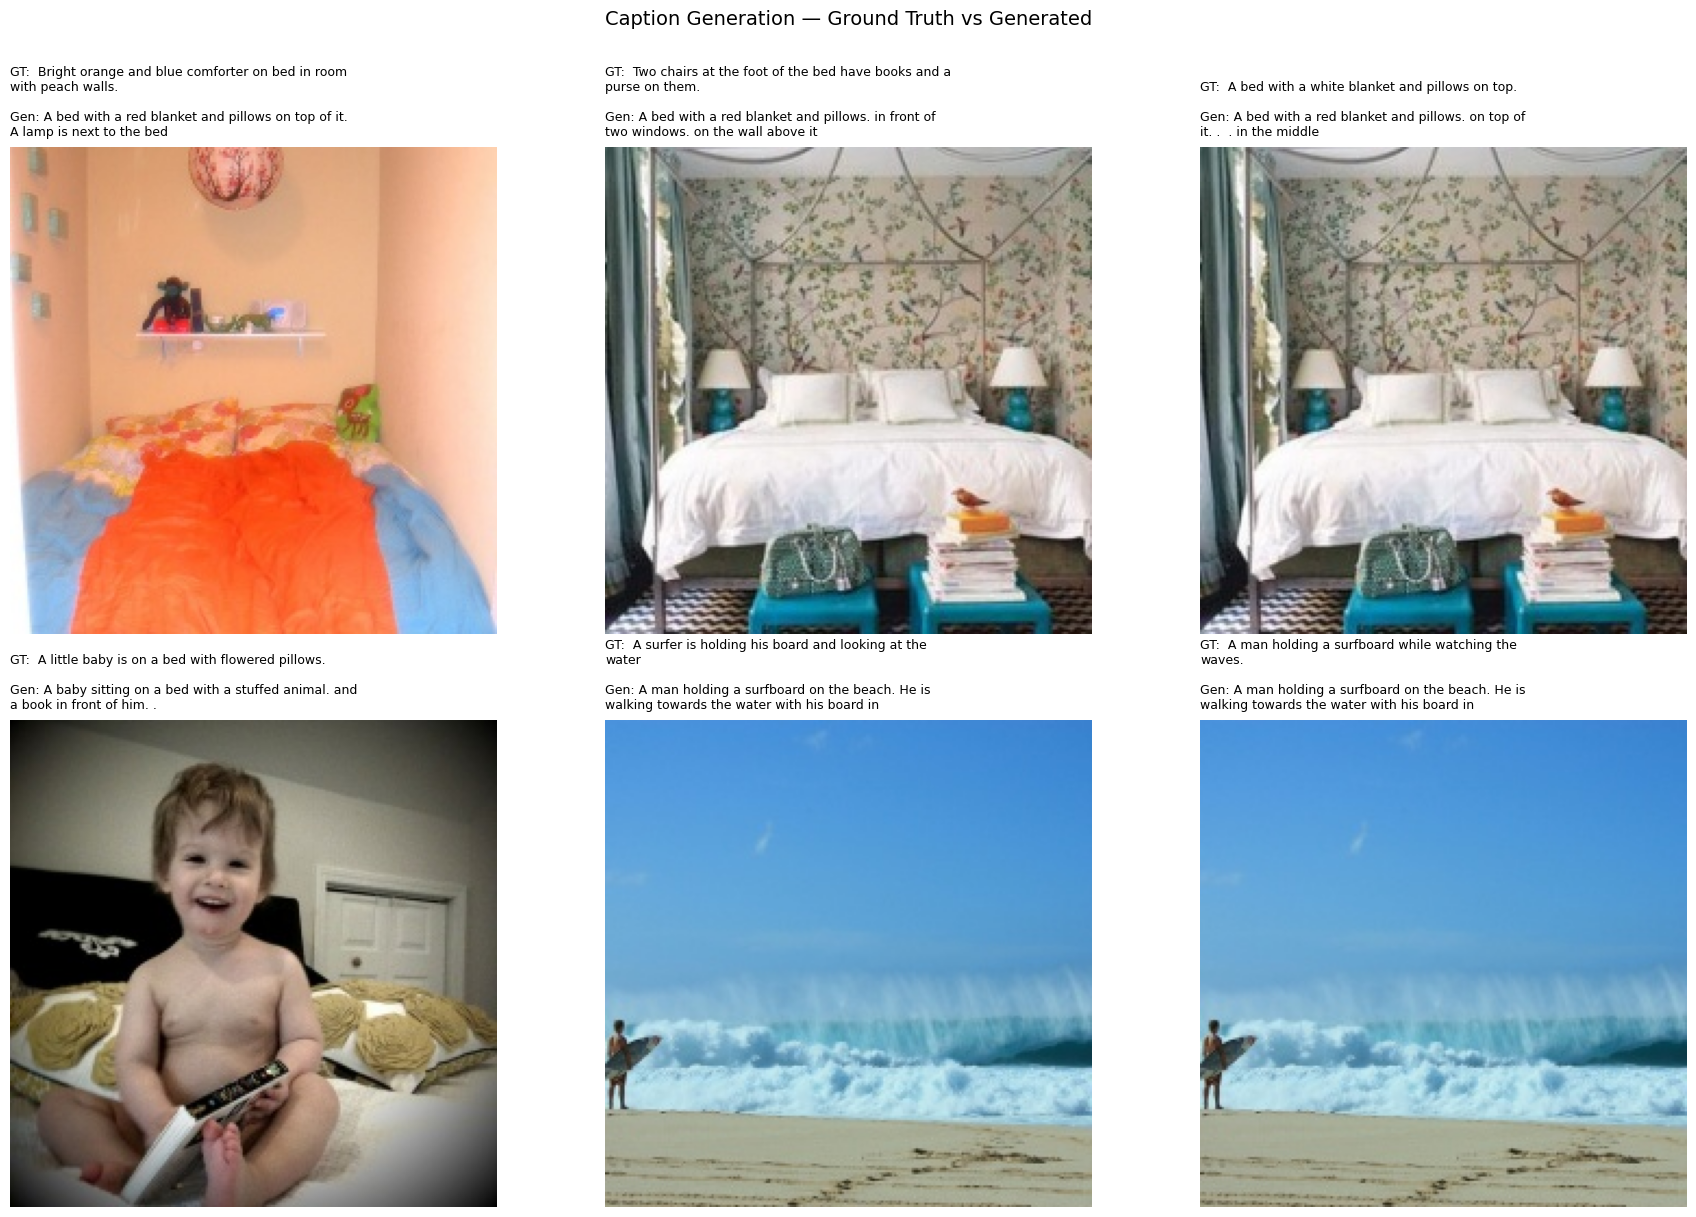

In [33]:
images, gt_captions = load_mscoco_samples(n=6, shard="00012")

print("Generating captions...")
generated_captions = [generate_caption(img,  temperature=0.1, max_new_tokens=20) for img in images]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (img, gt, gen) in enumerate(zip(images, gt_captions, generated_captions)):
    axes[i].imshow(img)
    axes[i].axis("off")
    gt_wrapped  = "\n".join(textwrap.wrap(f"GT:  {gt}",  width=55))
    gen_wrapped = "\n".join(textwrap.wrap(f"Gen: {gen}", width=55))
    axes[i].set_title(
        f"{gt_wrapped}\n\n{gen_wrapped}",
        fontsize=9, loc="left",
        color="black",
        pad=8,
    )

fig.suptitle("Caption Generation — Ground Truth vs Generated", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Experiment 2 — Effect of Different Prompts

Same image, different question prompts — tests how well the model follows instructions.

Generating responses for different prompts...



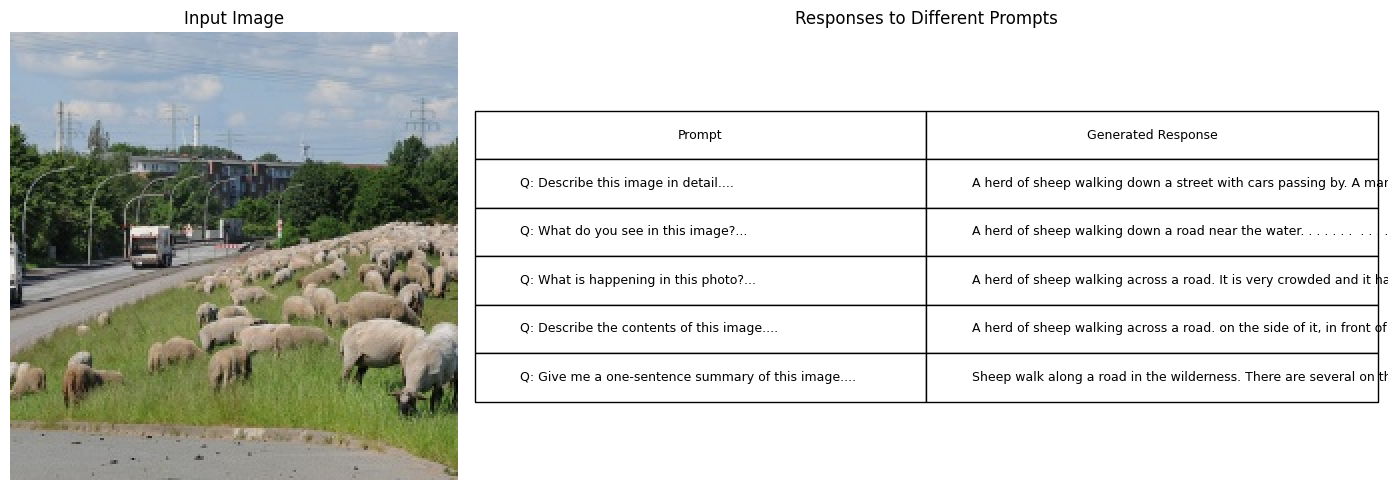

Full responses:

Prompt : Describe this image in detail.
Response: A herd of sheep walking down a street with cars passing by. A man stands in front of them while the sheep wander along behind him on the road.
a number of animals standing on some grass near buildings and trees, and car parked at other side of building. The animal is eating from it's left hand. One dog is looking over its head as another looks back to a truck that has

Prompt : What do you see in this image?
Response: A herd of sheep walking down a road near the water. . . . . . .  . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

Prompt : What is happening in this photo?
Response: A herd of sheep walking across a road. It is very crowded and it has cars in the background. The animals are crossing at an intersection with two people watching them from behind. A car sits parked on one side while another waits for a bus to pass by. There is no vehicle

In [5]:
images, _ = load_mscoco_samples(n=1, shard="00001")
test_image = images[0]

prompts = [
    "Describe this image in detail.",
    "What do you see in this image?",
    "What is happening in this photo?",
    "Describe the contents of this image.",
    "Give me a one-sentence summary of this image.",
]

print("Generating responses for different prompts...\n")
responses = [(p, generate_caption(test_image, prompt=p)) for p in prompts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(test_image)
axes[0].axis("off")
axes[0].set_title("Input Image", fontsize=12)

axes[1].axis("off")
table_data = [[f"Q: {p[:45]}...", f"{r[:80]}..."] if len(r) > 80 else [f"Q: {p[:45]}", r]
              for p, r in responses]
table = axes[1].table(
    cellText=table_data,
    colLabels=["Prompt", "Generated Response"],
    cellLoc="left",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)
axes[1].set_title("Responses to Different Prompts", fontsize=12)

plt.tight_layout()
plt.show()

print("Full responses:")
for p, r in responses:
    print(f"\nPrompt : {p}")
    print(f"Response: {r}")

## 6. Experiment 3 — Visual Question Answering

Ask specific questions about images. Tests whether the model can go beyond captioning.

Generating VQA responses...


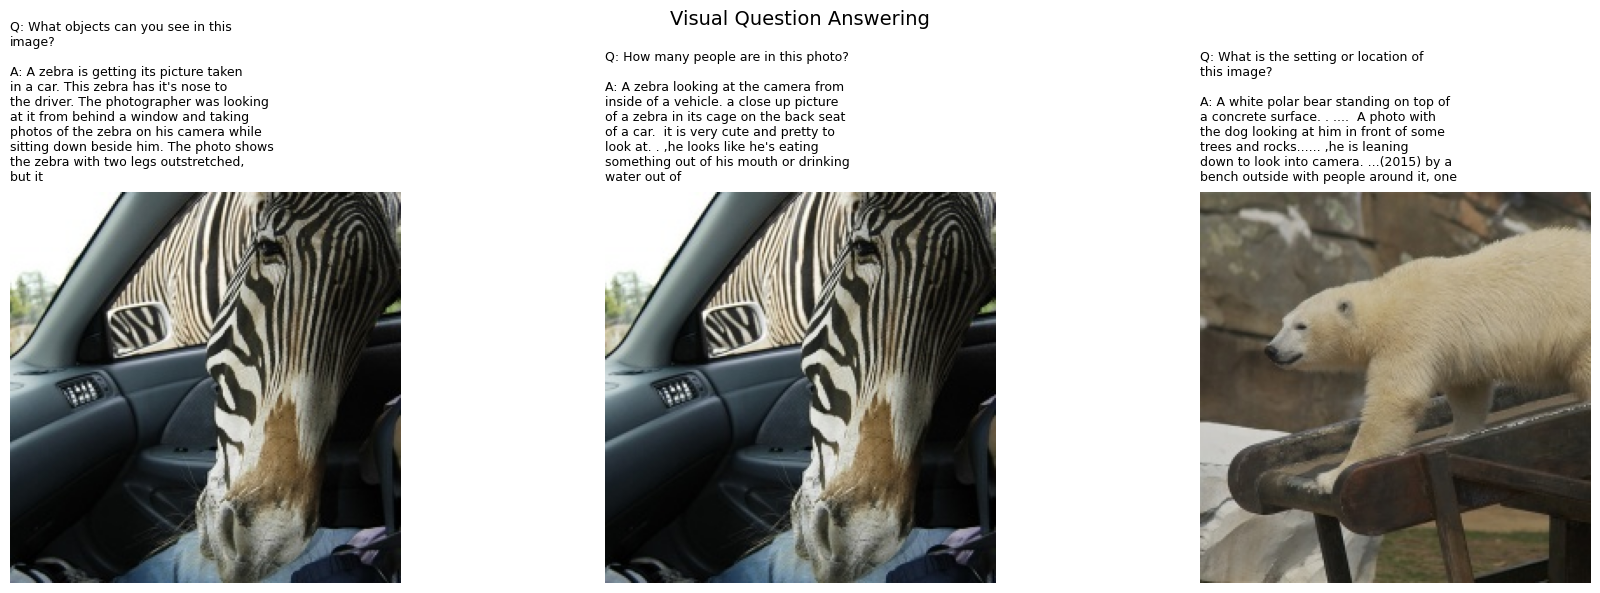

In [6]:
images, gt_captions = load_mscoco_samples(n=3, shard="00002")

# One question per image — edit these to match your images
questions = [
    "What objects can you see in this image?",
    "How many people are in this photo?",
    "What is the setting or location of this image?",
]

print("Generating VQA responses...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (img, gt, q) in enumerate(zip(images, gt_captions, questions)):
    answer = generate_caption(img, prompt=q, max_new_tokens=60)
    axes[i].imshow(img)
    axes[i].axis("off")
    q_wrapped = "\n".join(textwrap.wrap(f"Q: {q}", width=40))
    a_wrapped = "\n".join(textwrap.wrap(f"A: {answer}", width=40))
    axes[i].set_title(f"{q_wrapped}\n\n{a_wrapped}", fontsize=9, loc="left", pad=8)

fig.suptitle("Visual Question Answering", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Experiment 4 — Generation Parameters

Same image, varying `temperature` and `repetition_penalty` to understand their effect on output quality.

Generating with different parameters...

Low temp (deterministic):
  A man riding a skateboard down a ramp. at a skate park. with a crowd watching. behind him. and a man on a skateboard. in the background. and a man on a skateboard. in the foreground. and a man on a skateboard. in the background. and a man on a skateboard. behind him. and a man on a skateboard. in the

Default:
  A person on a skateboard doing tricks in the air. They are going fast, but they don't look very good at all times. (This is not a picture to be taken here). The man has his hand up as he holds onto an electric cable attached to him while riding down hill. This shows that there isn't enough room for one of these riders to do well with their skates and

High temp (creative):
  A man riding a skateboard up the side of  some ramps. in front of his friends. at night, on one part is another skater with long pants and short shorts while they do other things outside by each others' feet for breakfast on their laptop c

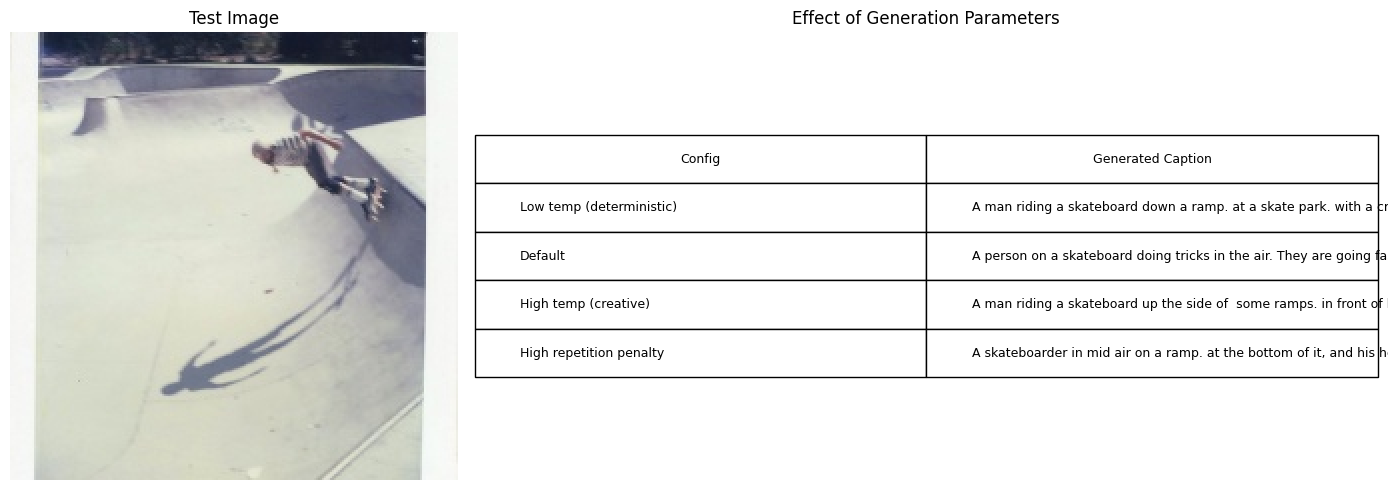

In [7]:
images, _ = load_mscoco_samples(n=1, shard="00003")
test_image = images[0]

configs = [
    {"temperature": 0.3, "repetition_penalty": 1.0, "label": "Low temp (deterministic)"},
    {"temperature": 0.7, "repetition_penalty": 1.2, "label": "Default"},
    {"temperature": 1.0, "repetition_penalty": 1.2, "label": "High temp (creative)"},
    {"temperature": 0.7, "repetition_penalty": 1.5, "label": "High repetition penalty"},
]

print("Generating with different parameters...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(test_image)
axes[0].axis("off")
axes[0].set_title("Test Image")

axes[1].axis("off")
rows = []
for cfg in configs:
    response = generate_caption(
        test_image,
        temperature=cfg["temperature"],
        repetition_penalty=cfg["repetition_penalty"],
    )
    rows.append([cfg["label"], response[:90] + "..." if len(response) > 90 else response])
    print(f"{cfg['label']}:\n  {response}\n")

table = axes[1].table(
    cellText=rows,
    colLabels=["Config", "Generated Caption"],
    cellLoc="left",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)
axes[1].set_title("Effect of Generation Parameters")

plt.tight_layout()
plt.show()

## 8. Experiment 5 — Custom Image

Test the model on any image you provide. Just change `IMAGE_PATH` below.

Prompt  : Describe this image in detail.
Response: A man wearing a helmet standing next to his motorcycle. .he is holding the handlebars of an old style motor cycle.  He has been out for several hours on this bike. and he looks at something in front of him while sitting down with his hands behind him, as if they are pushing him up into the air. The other person's feet have fallen forward. Near by, he stands

Prompt  : What objects are in this image?
Response: A man in a black jacket is standing near motorcycles. The motorcycle has the words "Tourist" written on it's side and the back of its body. An older motorcycle parked next to a bus. A bicycle sits by an old building with brick walls and graffiti all over them, as if they are both being used for some sort of event or display. (This photograph shows the rear view

Prompt  : What is happening in this photo?
Response: A man in a black jacket sitting next to his motorcycle. The motorcycle is parked on the side of the road. A person hol

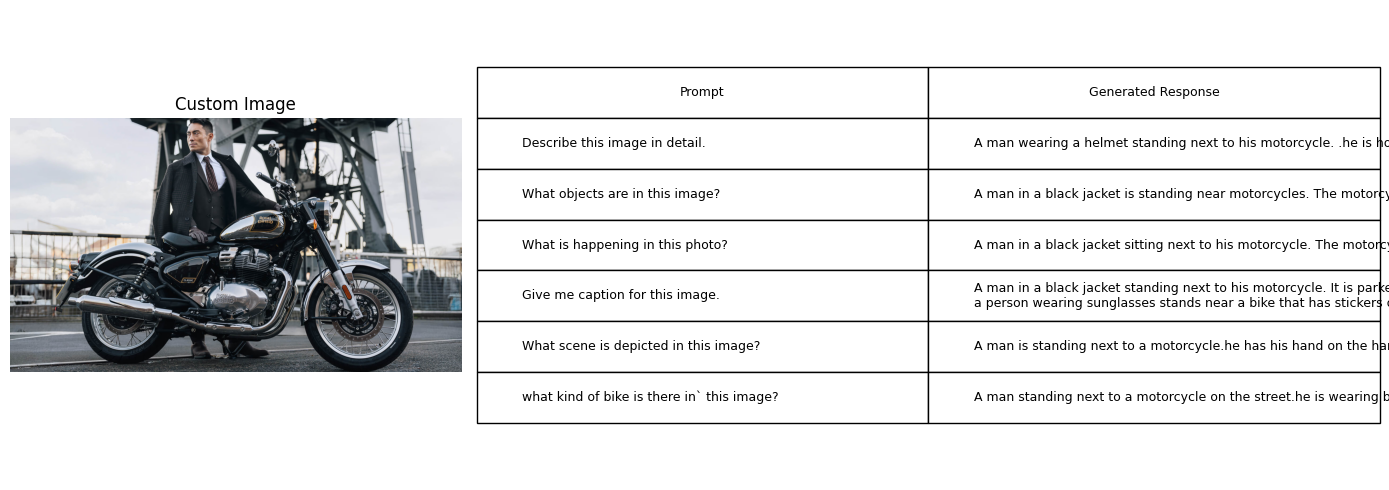

In [15]:
IMAGE_PATH = "D:\Machine_learning\Projects\BLIP-VLM\images_test\download (3).jpg"   # ← change this

custom_prompts = [
    "Describe this image in detail.",
    "What objects are in this image?",
    "What is happening in this photo?",
    "Give me caption for this image.",
    "What scene is depicted in this image?",
    "what kind of bike is there in` this image?",
]

if not os.path.exists(IMAGE_PATH):
    print("IMAGE_PATH does not exist — skipping. Update the path above.")
else:
    custom_image = Image.open(IMAGE_PATH).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})
    axes[0].imshow(custom_image)
    axes[0].axis("off")
    axes[0].set_title("Custom Image")

    axes[1].axis("off")
    rows = []
    for p in custom_prompts:
        response = generate_caption(custom_image, prompt=p)
        rows.append([p[:50], response])
        print(f"Prompt  : {p}")
        print(f"Response: {response}\n")

    table = axes[1].table(
        cellText=rows,
        colLabels=["Prompt", "Generated Response"],
        cellLoc="left",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.5)

    plt.tight_layout()
    plt.show()